```
    ██████╗ ████████╗ █████╗      ██╗██╗     ██████╗██████╗ ███████╗██╗    ██╗
    ██╔══██╗╚══██╔══╝██╔══██╗     ██║██║    ██╔════╝██╔══██╗██╔════╝██║    ██║
    ██████╔╝   ██║   ███████║     ██║██║    ██║     ██████╔╝█████╗  ██║ █╗ ██║
    ██╔══██╗   ██║   ██╔══██║██   ██║██║    ██║     ██╔══██╗██╔══╝  ██║███╗██║
    ██████╔╝   ██║   ██║  ██║╚█████╔╝██║    ╚██████╗██║  ██║███████╗╚███╔███╔╝
    ╚═════╝    ╚═╝   ╚═╝  ╚═╝ ╚════╝ ╚═╝     ╚═════╝╚═╝  ╚═╝╚══════╝ ╚══╝╚══╝
```

**Natural Language Processing Project - WhatsApp Group Chat Analysis**

Analyzing communication patterns, member activity, and conversation insights from BTAJI CREW using Python and NLP techniques.

**Dataset:** WhatsApp Export (Private) | **Period:** Oct 2024 - Nov 2025 | **Members:** 7 | **Messages:** 20K+

---

![image](https://i.postimg.cc/SxSB1cd5/Gemini-Generated-Image-proifqproifqproi.png)

## 📚 Step 1: Import Libraries

Install if needed: `pip install pandas matplotlib seaborn wordcloud plotly`

In [2]:
# Import all required libraries
import re
import pandas as pd
import numpy as np
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📖 Step 2: Load and Parse WhatsApp Chat

**Change the file path to your location!**

In [3]:
# data path ( if u wanna use change path ok as i didnt share anywhere it was personal data =)
file_path = r'/kaggle/input/btaji-whatsapp-chat/WhatsApp Chat with General.txt'

# Read the file
with open(file_path, 'r', encoding='utf-8') as f:
    content = f.read()

print(f"✅ File loaded successfully!")
print(f"Total characters: {len(content):,}")

✅ File loaded successfully!
Total characters: 1,908,953


## 🔍 Step 3: Parse Messages into DataFrame

In [4]:
# Pattern to match WhatsApp messages
pattern = r'(\d{1,2}/\d{1,2}/\d{2}), (\d{1,2}:\d{2}\s[AP]M) - ([^:]+):\s?(.*?)(?=\d{1,2}/\d{1,2}/\d{2}, \d{1,2}:\d{2}\s[AP]M -|\Z)'

matches = re.findall(pattern, content, re.DOTALL)

print(f"📊 Found {len(matches)} messages")

# Create DataFrame
data = []
for match in matches:
    date_str, time_str, sender, message = match
    
    # Parse datetime
    dt_str = f"{date_str}, {time_str}"
    try:
        dt = datetime.strptime(dt_str, "%m/%d/%y, %I:%M %p")
    except:
        continue
    
    # Clean message
    message = message.strip()
    
    data.append({
        'date': dt.date(),
        'time': dt.time(),
        'datetime': dt,
        'sender': sender.strip(),
        'message': message,
        'day_of_week': dt.strftime('%A'),
        'hour': dt.hour,
        'month': dt.strftime('%B %Y'),
        'year': dt.year
    })

df = pd.DataFrame(data)

print(f"\n✅ Created DataFrame with {len(df):,} messages")
print(f"\n📅 Date Range: {df['date'].min()} to {df['date'].max()}")

📊 Found 20938 messages

✅ Created DataFrame with 20,938 messages

📅 Date Range: 2024-10-07 to 2025-11-15


## 🧹 Step 4: Clean Data - Remove System Messages

In [5]:
# System message patterns
system_patterns = [
    'added you', 'joined using', 'joined from', 'left', 'changed the group',
    'pinned a message', 'Messages and calls', 'Members in this group',
    'Only messages', 'You added', 'You changed', 'You removed', 'You pinned',
    'Meta AI', "You're now", 'created group'
]

def is_system_message(sender):
    return any(pattern in sender for pattern in system_patterns)

# Filter out system messages
original_count = len(df)
df = df[~df['sender'].apply(is_system_message)].copy()

print(f"🧹 Removed {original_count - len(df)} system messages")
print(f"✅ Clean dataset: {len(df):,} user messages")

🧹 Removed 39 system messages
✅ Clean dataset: 20,899 user messages


## 👥 Step 5: Normalize Member Names

**Merge same people with different accounts (like Asim with multiple numbers)**

In [6]:
# Show unique senders
print("📋 Unique senders found:")
for i, sender in enumerate(sorted(df['sender'].unique()), 1):
    count = len(df[df['sender'] == sender])
    print(f"{i}. {sender}: {count} messages")

📋 Unique senders found:
1. Ahmad Fakhar Codanics: 3734 messages
2. Asim Hackathon 2 ( 12 Feb ): 2343 messages
3. Asim Khan O1 Hackathon: 501 messages
4. Bilal IBM Watson: 1683 messages
5. Hassan Mehmood iCode Guru: 250 messages
6. Ibrahim: 6351 messages
7. Jawad Codanics: 2322 messages
8. Tayyab Sajjad: 3715 messages


In [7]:
# Create name mapping (merge similar names)
name_mapping = {}

for sender in df['sender'].unique():
    # Normalize names
    if 'Asim' in sender:
        name_mapping[sender] = 'Asim'
    elif 'Ahmad' in sender:
        name_mapping[sender] = 'Ahmad'
    elif 'Ibrahim' in sender:
        name_mapping[sender] = 'Ibrahim'
    elif 'Jawad' in sender:
        name_mapping[sender] = 'Jawad'
    elif 'Bilal' in sender:
        name_mapping[sender] = 'Bilal'
    elif 'Tayyab' in sender:
        name_mapping[sender] = 'Tayyab'
    elif 'Hassan' in sender:
        name_mapping[sender] = 'Hassan'
    else:
        name_mapping[sender] = sender

# Apply mapping
df['sender'] = df['sender'].map(name_mapping)

print("✅ Name normalization complete!")
print(f"\n👥 Final member list: {df['sender'].nunique()} members")
print(df['sender'].value_counts())

✅ Name normalization complete!

👥 Final member list: 7 members
sender
Ibrahim    6351
Ahmad      3734
Tayyab     3715
Asim       2844
Jawad      2322
Bilal      1683
Hassan      250
Name: count, dtype: int64


## 📊 Step 6: Add Additional Features

In [8]:
# Calculate message features
df['message_length'] = df['message'].str.len()
df['word_count'] = df['message'].str.split().str.len()
df['is_media'] = df['message'].str.contains('<Media omitted>', na=False)
df['has_link'] = df['message'].str.contains('http', na=False)
df['has_emoji'] = df['message'].str.contains('[😀-🙏🌀-🗿🚀-🛿]', na=False, regex=True)

# Time features
df['is_night'] = df['hour'].apply(lambda x: 1 if (x >= 0 and x < 6) else 0)
df['is_morning'] = df['hour'].apply(lambda x: 1 if (x >= 6 and x < 12) else 0)
df['is_afternoon'] = df['hour'].apply(lambda x: 1 if (x >= 12 and x < 18) else 0)
df['is_evening'] = df['hour'].apply(lambda x: 1 if (x >= 18 and x < 24) else 0)

print("✅ Features added!")
print(f"\n📝 Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

✅ Features added!

📝 Dataset shape: (20899, 18)

Columns: ['date', 'time', 'datetime', 'sender', 'message', 'day_of_week', 'hour', 'month', 'year', 'message_length', 'word_count', 'is_media', 'has_link', 'has_emoji', 'is_night', 'is_morning', 'is_afternoon', 'is_evening']


## 📈 Step 7: Basic Statistics

In [9]:
print("="*80)
print("📊 BASIC STATISTICS")
print("="*80)

print(f"\n📱 Total Messages: {len(df):,}")
print(f"👥 Total Members: {df['sender'].nunique()}")
print(f"📅 Date Range: {df['date'].min()} to {df['date'].max()}")
print(f"🗓️ Active Days: {df['date'].nunique()}")
print(f"📊 Avg Messages/Day: {len(df) / df['date'].nunique():.1f}")

print(f"\n📷 Media Shared: {df['is_media'].sum():,}")
print(f"🔗 Links Shared: {df['has_link'].sum():,}")
print(f"😊 Messages with Emoji: {df['has_emoji'].sum():,}")

print(f"\n💬 Average Message Length: {df['message_length'].mean():.1f} characters")
print(f"📝 Average Word Count: {df['word_count'].mean():.1f} words")

print("\n" + "="*80)

📊 BASIC STATISTICS

📱 Total Messages: 20,899
👥 Total Members: 7
📅 Date Range: 2024-10-07 to 2025-11-15
🗓️ Active Days: 376
📊 Avg Messages/Day: 55.6

📷 Media Shared: 3,820
🔗 Links Shared: 1,089
😊 Messages with Emoji: 1,074

💬 Average Message Length: 53.6 characters
📝 Average Word Count: 7.6 words



## 🎨 Step 8:  Messages per Member 

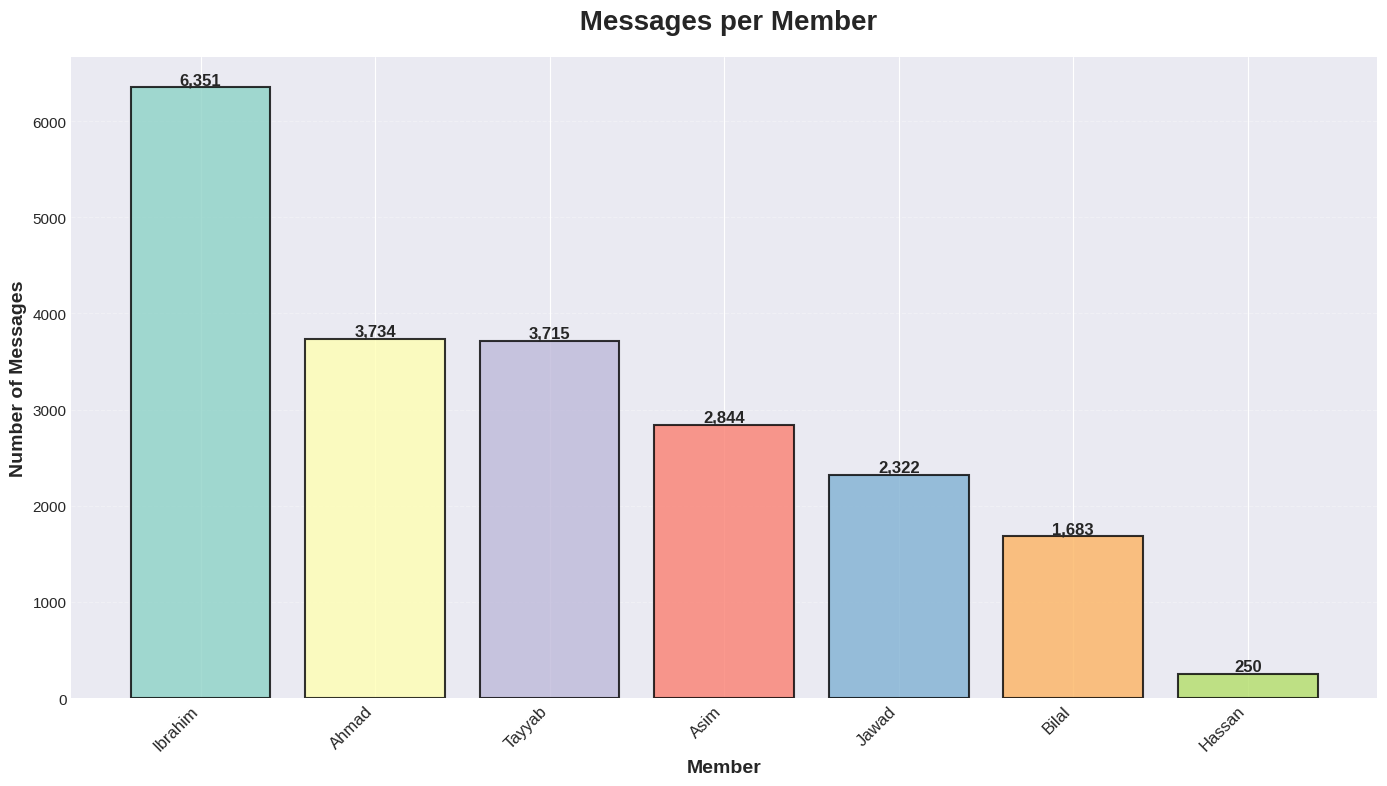

✅ Chart created!


In [10]:
# Create beautiful bar chart
member_counts = df['sender'].value_counts()

fig = plt.figure(figsize=(14, 8))
colors = plt.cm.Set3(range(len(member_counts)))

bars = plt.bar(member_counts.index, member_counts.values, color=colors, 
               edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title(' Messages per Member', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Member', fontsize=14, fontweight='bold')
plt.ylabel('Number of Messages', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("✅ Chart created!")

## 🕐 Step 9: Visualization 2 - Activity by Hour (Line + Area Chart)

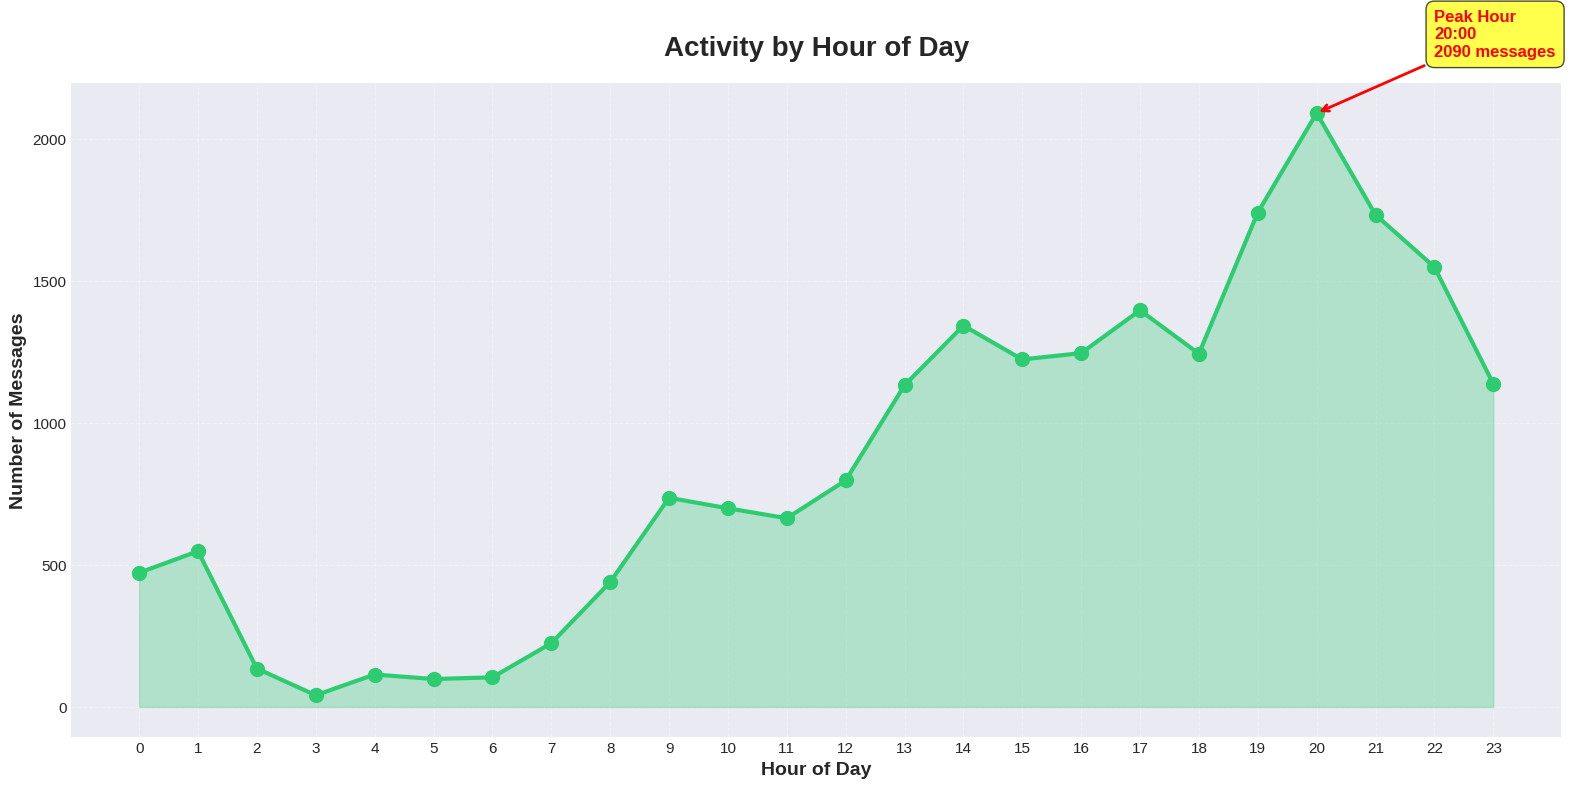

✅ Peak activity at 20:00 with 2090 messages!


In [11]:
hour_counts = df['hour'].value_counts().sort_index()

fig = plt.figure(figsize=(16, 8))
plt.plot(hour_counts.index, hour_counts.values, marker='o', 
         linewidth=3, markersize=10, color='#2ecc71', label='Messages')
plt.fill_between(hour_counts.index, hour_counts.values, alpha=0.3, color='#2ecc71')

# Add peak hour annotation
peak_hour = hour_counts.idxmax()
peak_value = hour_counts.max()
plt.annotate(f'Peak Hour\n{peak_hour}:00\n{peak_value} messages', 
             xy=(peak_hour, peak_value), xytext=(peak_hour+2, peak_value+200),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=12, fontweight='bold', color='red',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.title('Activity by Hour of Day', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Hour of Day', fontsize=14, fontweight='bold')
plt.ylabel('Number of Messages', fontsize=14, fontweight='bold')
plt.xticks(range(24), fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"✅ Peak activity at {peak_hour}:00 with {peak_value} messages!")

## 📅 Step 10: Visualization 3 - Activity by Day of Week

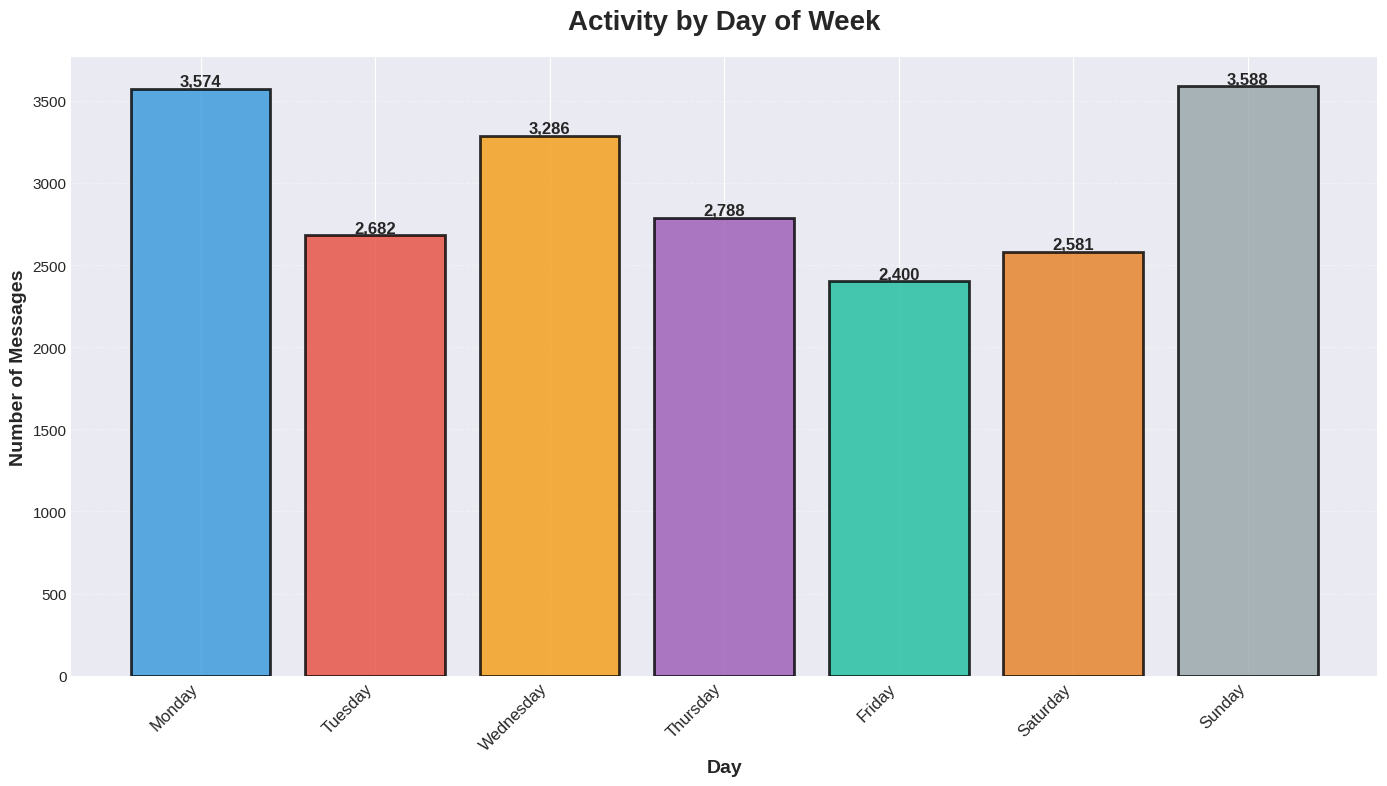

✅ Most active day: Sunday with 3,588 messages!


In [12]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)

fig = plt.figure(figsize=(14, 8))
colors = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']
bars = plt.bar(day_counts.index, day_counts.values, color=colors, 
               edgecolor='black', linewidth=2, alpha=0.8)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Activity by Day of Week', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Day', fontsize=14, fontweight='bold')
plt.ylabel('Number of Messages', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"✅ Most active day: {day_counts.idxmax()} with {day_counts.max():,} messages!")

## 📈 Step 11: Visualization 4 - Messages Over Time (Timeline)

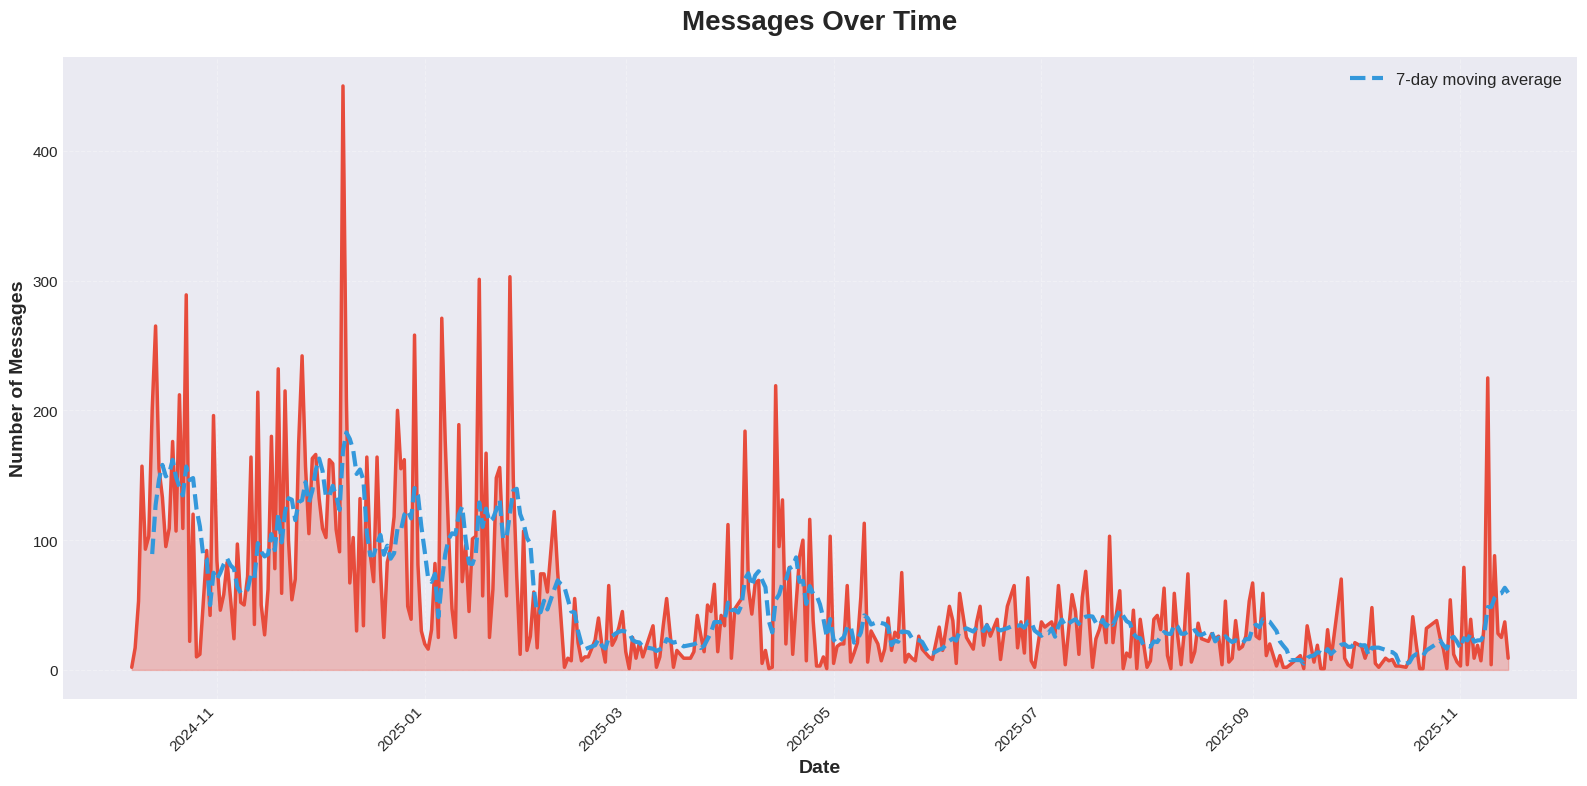

✅ Timeline created!


In [13]:
daily_messages = df.groupby('date').size()

fig = plt.figure(figsize=(16, 8))
plt.plot(daily_messages.index, daily_messages.values, linewidth=2.5, color='#e74c3c')
plt.fill_between(daily_messages.index, daily_messages.values, alpha=0.3, color='#e74c3c')

# Add moving average
rolling_avg = daily_messages.rolling(window=7).mean()
plt.plot(rolling_avg.index, rolling_avg.values, linewidth=3, 
         color='#3498db', label='7-day moving average', linestyle='--')

plt.title('Messages Over Time', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=14, fontweight='bold')
plt.ylabel('Number of Messages', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print("✅ Timeline created!")

## 🔥 Step 12: Visualization 5 - Activity Heatmap (Day × Hour)

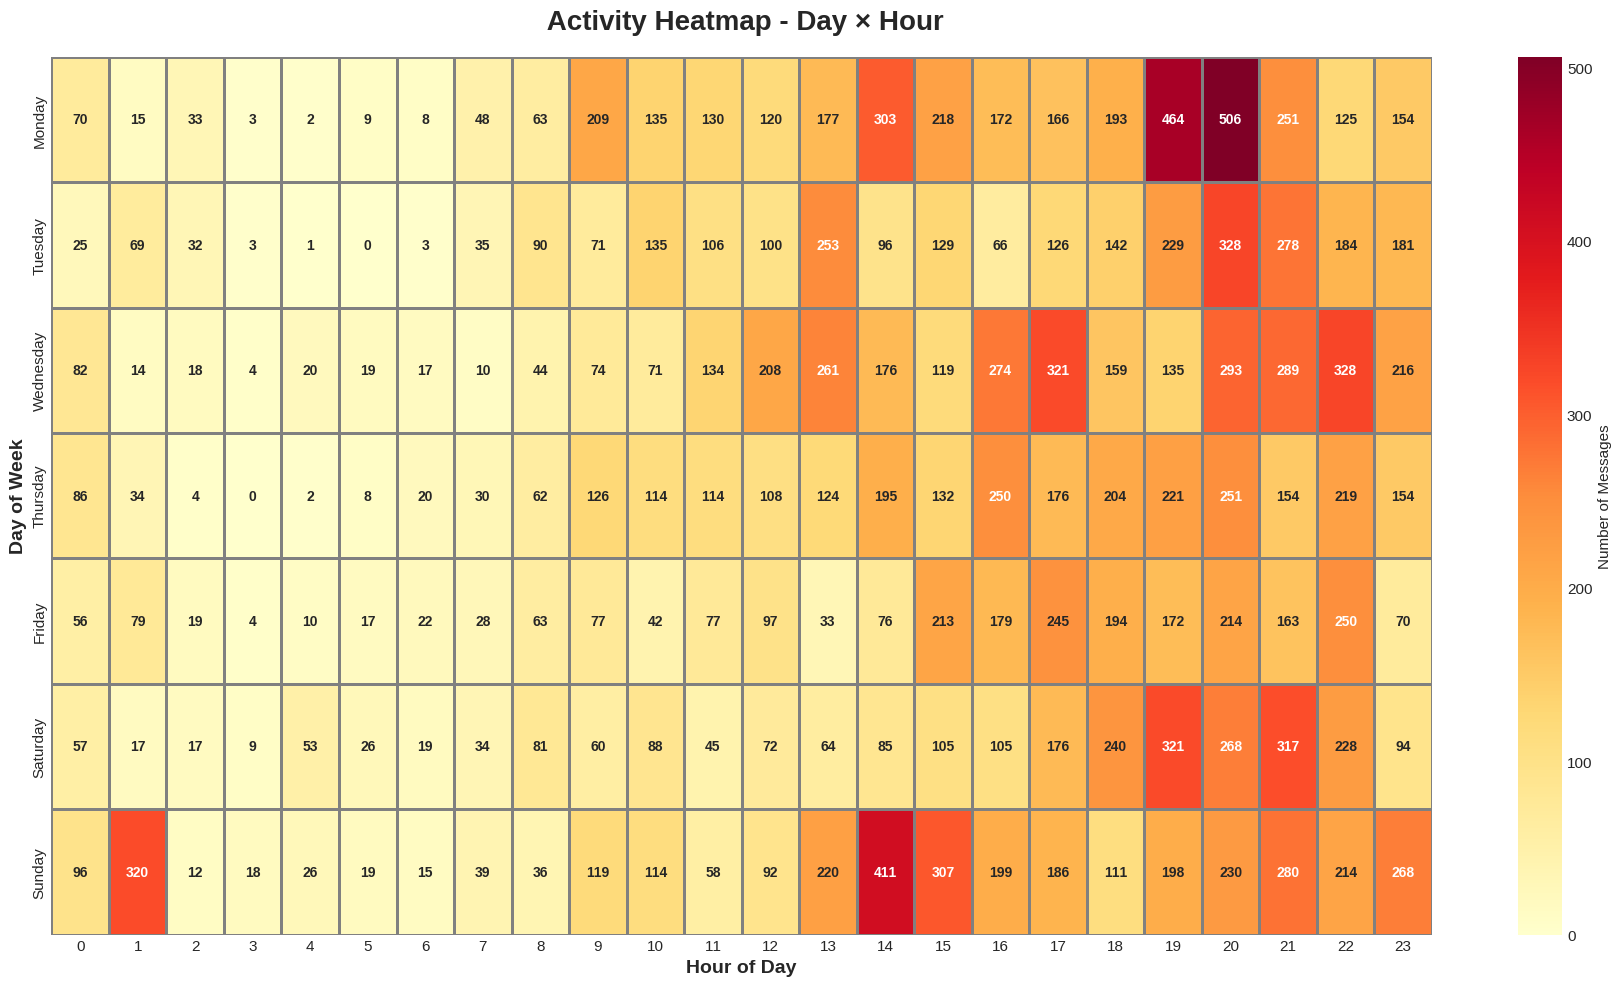

✅ Heatmap created!


In [14]:
# Create pivot table
pivot_data = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
pivot_data = pivot_data.reindex(day_order)

fig = plt.figure(figsize=(18, 10))
sns.heatmap(pivot_data, cmap='YlOrRd', annot=True, fmt='d', 
            linewidths=1, linecolor='gray',
            cbar_kws={'label': 'Number of Messages'},
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})

plt.title(' Activity Heatmap - Day × Hour', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Hour of Day', fontsize=14, fontweight='bold')
plt.ylabel('Day of Week', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Heatmap created!")

## ☁️ Step 13: Visualization 6 - Word Cloud

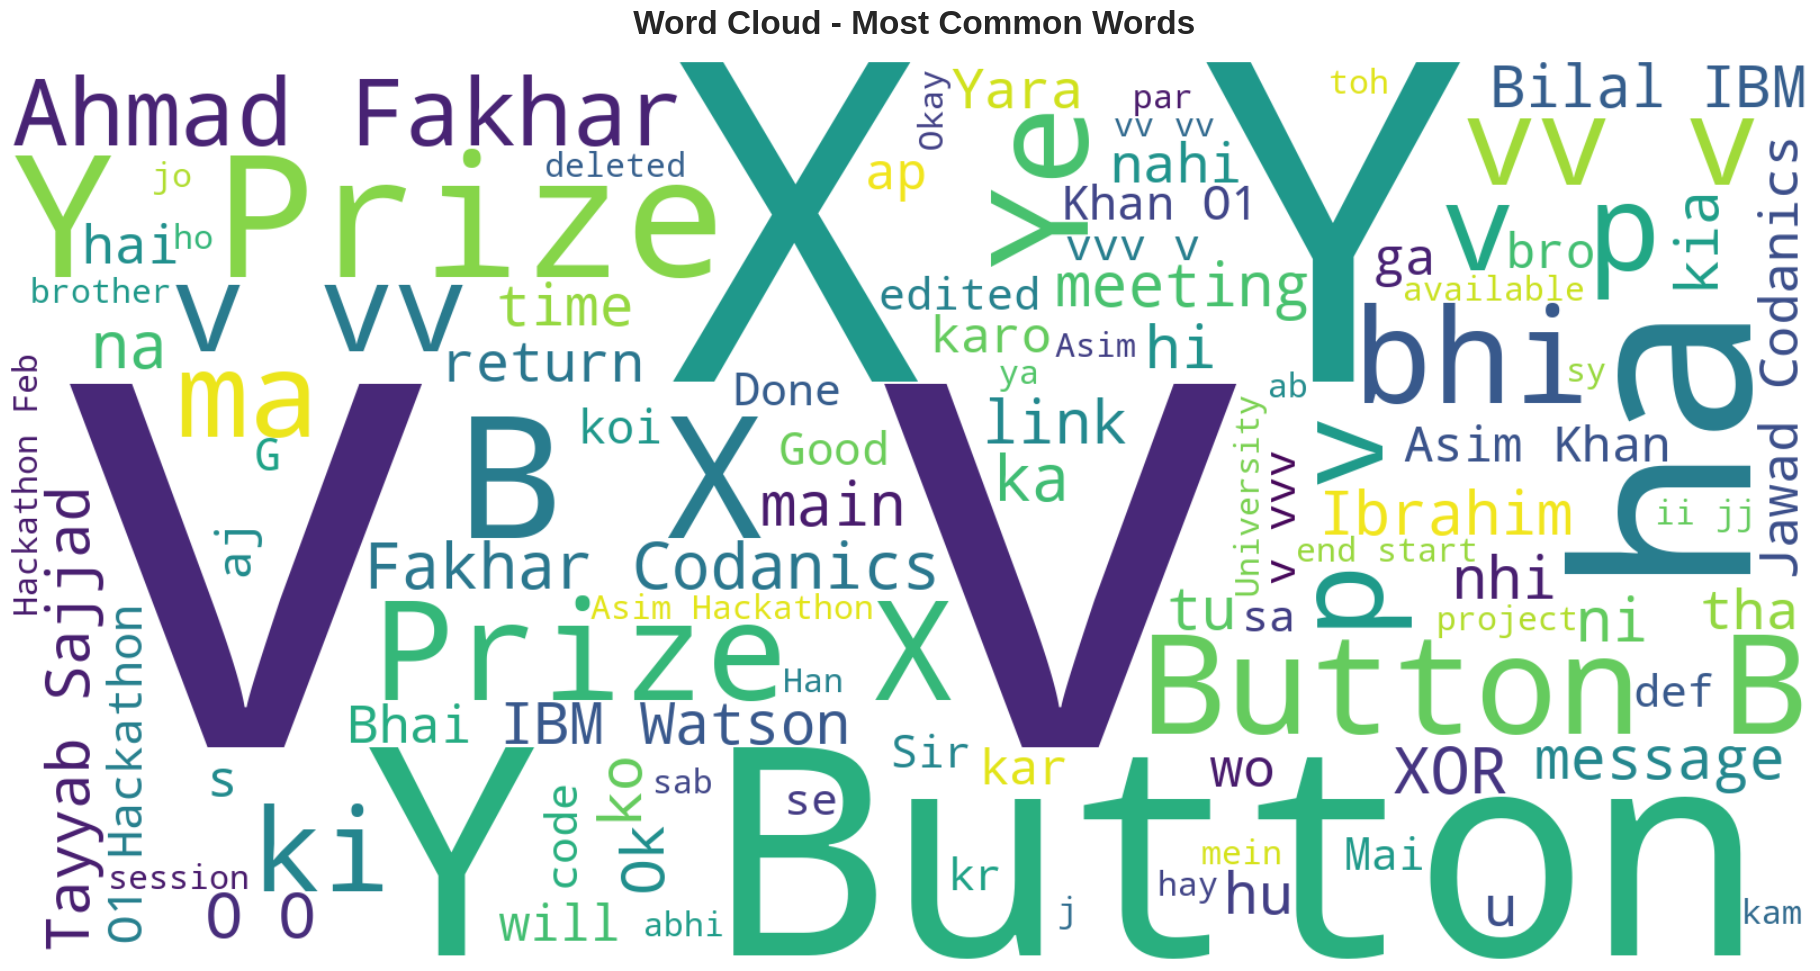

✅ Word cloud created!


In [15]:
# Prepare text
all_text = ' '.join(df['message'].astype(str))
all_text = re.sub(r'http\S+', '', all_text)  # Remove URLs
all_text = re.sub(r'<Media omitted>', '', all_text)  # Remove media tags

# Create word cloud
fig = plt.figure(figsize=(18, 10))
wordcloud = WordCloud(width=1600, height=800, 
                     background_color='white',
                     colormap='viridis',
                     max_words=100,
                     relative_scaling=0.5,
                     min_font_size=10).generate(all_text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(' Word Cloud - Most Common Words', fontsize=24, fontweight='bold', pad=20)
plt.tight_layout(pad=0)
plt.show()

print("✅ Word cloud created!")

## 👥 Step 14: Visualization 7 - Member Comparison (4-Panel)

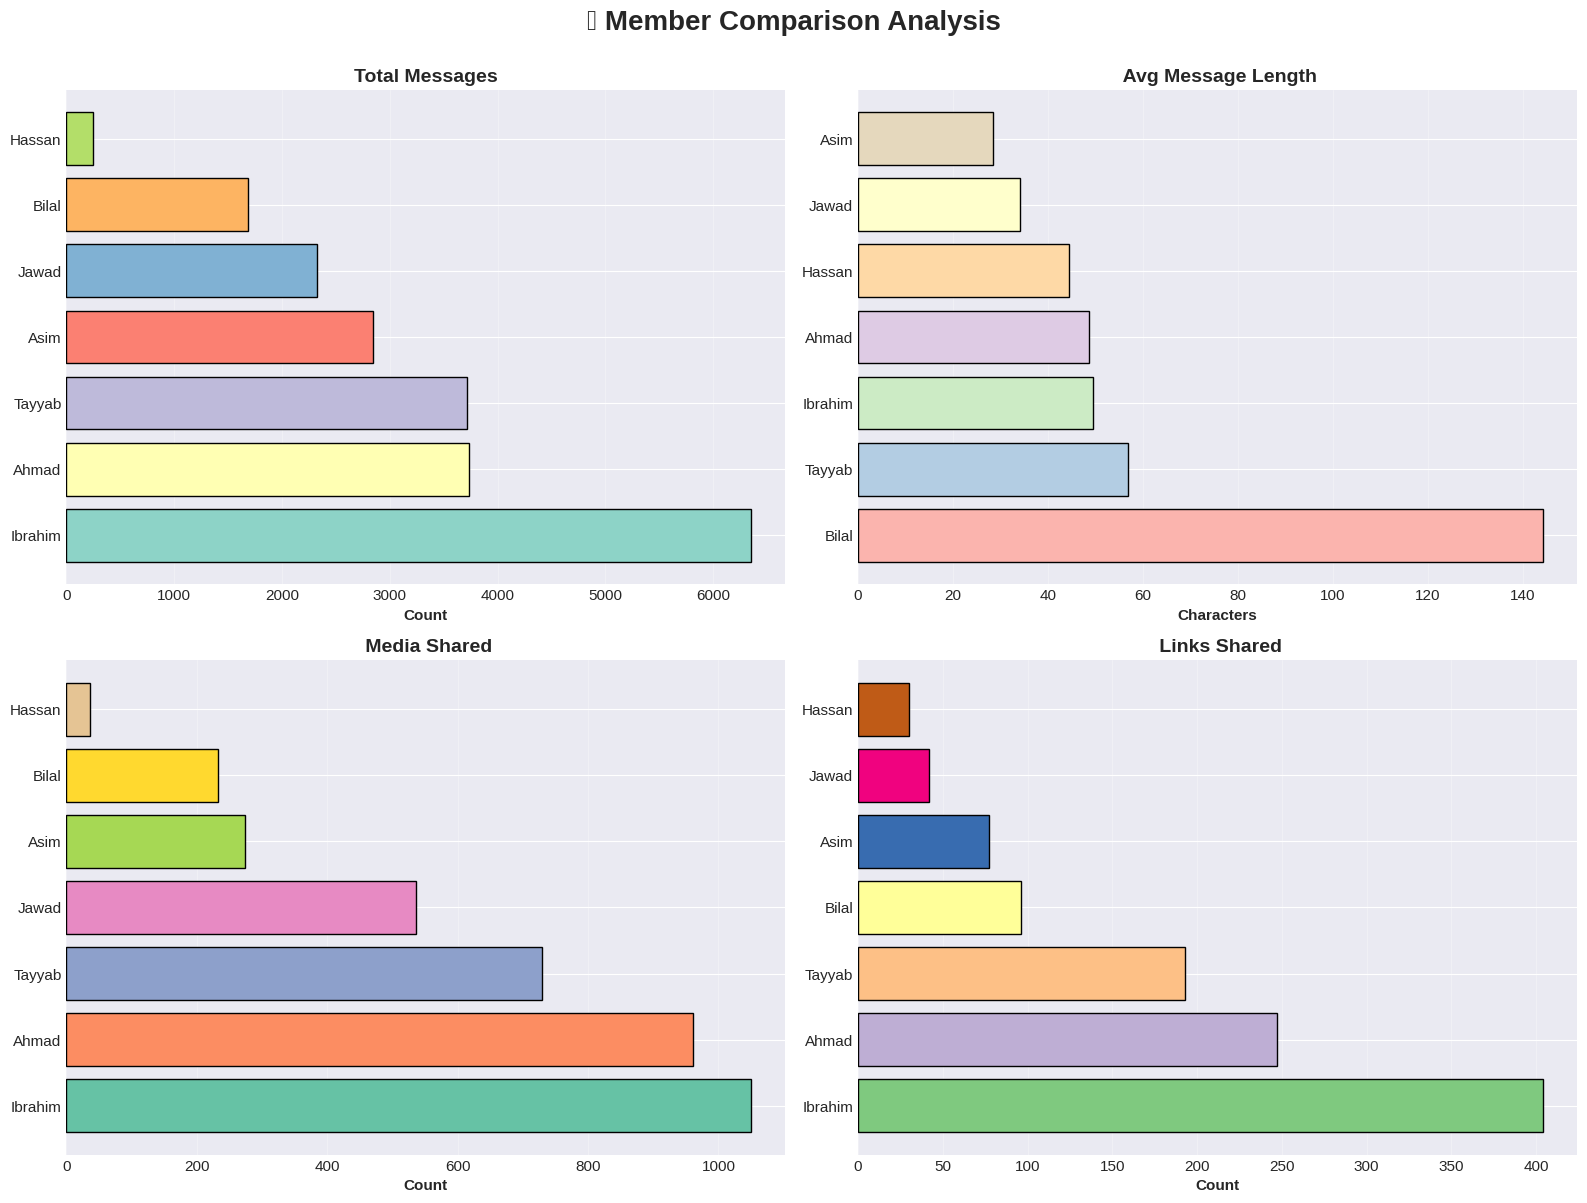

✅ Member comparison created!


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('👥 Member Comparison Analysis', fontsize=20, fontweight='bold', y=1.00)

# 1. Total Messages
member_counts = df['sender'].value_counts()
colors = plt.cm.Set3(range(len(member_counts)))
axes[0, 0].barh(member_counts.index, member_counts.values, color=colors, edgecolor='black')
axes[0, 0].set_title('Total Messages', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Count', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Average Message Length
avg_length = df.groupby('sender')['message_length'].mean().sort_values(ascending=False)
colors = plt.cm.Pastel1(range(len(avg_length)))
axes[0, 1].barh(avg_length.index, avg_length.values, color=colors, edgecolor='black')
axes[0, 1].set_title(' Avg Message Length', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Characters', fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. Media Shared
media_counts = df[df['is_media']].groupby('sender').size().sort_values(ascending=False)
colors = plt.cm.Set2(range(len(media_counts)))
axes[1, 0].barh(media_counts.index, media_counts.values, color=colors, edgecolor='black')
axes[1, 0].set_title(' Media Shared', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Count', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Links Shared
link_counts = df[df['has_link']].groupby('sender').size().sort_values(ascending=False)
colors = plt.cm.Accent(range(len(link_counts)))
axes[1, 1].barh(link_counts.index, link_counts.values, color=colors, edgecolor='black')
axes[1, 1].set_title(' Links Shared', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Count', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Member comparison created!")

## 🎯 Step 15: Interactive Plotly Chart - Messages Over Time

In [17]:

daily_by_member = df.groupby(['date', 'sender']).size().reset_index(name='count')

fig = px.line(daily_by_member, x='date', y='count', color='sender',
              title=' Interactive Timeline - Messages by Member',
              labels={'count': 'Number of Messages', 'date': 'Date', 'sender': 'Member'},
              template='plotly_white')

fig.update_layout(
    font=dict(size=14),
    title_font_size=20,
    hovermode='x unified',
    height=600
)

fig.show()

print("✅ Interactive chart created! (You can zoom, pan, and hover!)")

✅ Interactive chart created! (You can zoom, pan, and hover!)


## 📝 Step 16: Word Frequency Analysis

Top 30 Most Common Words:

 1. button               - 1293 times
 2. bhi                  -  765 times
 3. prize:               -  640 times
 4. codanics⁩            -  519 times
 5. you                  -  494 times
 6. meeting              -  466 times
 7. return               -  447 times
 8. kar                  -  408 times
 9. nhi                  -  398 times
10. kia                  -  394 times
11. xor                  -  360 times
12. raha                 -  342 times
13. tha                  -  341 times
14. fakhar               -  334 times
15. link                 -  334 times
16. @⁨ahmad              -  314 times
17. was                  -  306 times
18. not                  -  299 times
19. @⁨asim               -  284 times
20. main                 -  281 times
21. yes                  -  278 times
22. def                  -  272 times
23. message              -  261 times
24. yara                 -  258 times
25. nahi                 -  253 times
26. your               

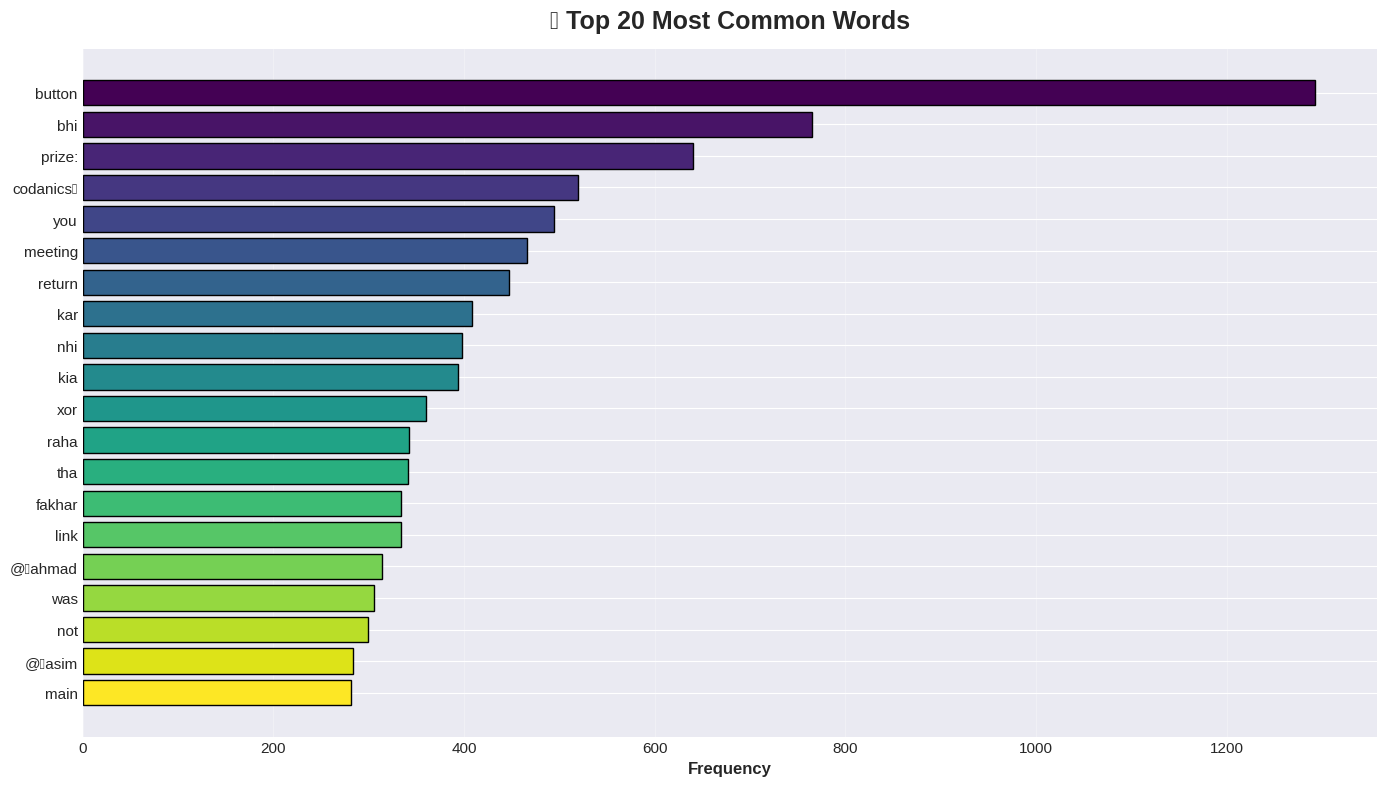

In [18]:
# Get all words
all_text = ' '.join(df['message'].astype(str))
all_text = re.sub(r'http\S+', '', all_text)
all_text = re.sub(r'<Media omitted>', '', all_text)
words = all_text.lower().split()

# Remove short words and common stop words
stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 
             'of', 'is', 'it', 'this', 'that', 'with', 'as', 'by', 'from'}
words = [w for w in words if len(w) > 2 and w not in stop_words]

word_counts = Counter(words)

print("Top 30 Most Common Words:\n")
for i, (word, count) in enumerate(word_counts.most_common(30), 1):
    print(f"{i:2d}. {word:20s} - {count:4d} times")

# Visualize top 20
top_words = dict(word_counts.most_common(20))

fig = plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 1, 20))
plt.barh(list(top_words.keys()), list(top_words.values()), color=colors, edgecolor='black')
plt.title('🔤 Top 20 Most Common Words', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Frequency', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## ⚡ Step 17: Response Time Analysis

 RESPONSE TIME ANALYSIS
Average Response Time: 2.85 minutes
Median Response Time: 0.00 minutes
Fastest Response: 0.00 minutes

👥 Average Response Time by Member:
  Ibrahim        : 2.74 minutes
  Ahmad          : 2.94 minutes
  Bilal          : 4.04 minutes
  Asim           : 2.36 minutes
  Jawad          : 2.97 minutes
  Tayyab         : 2.82 minutes
  Hassan         : 1.80 minutes


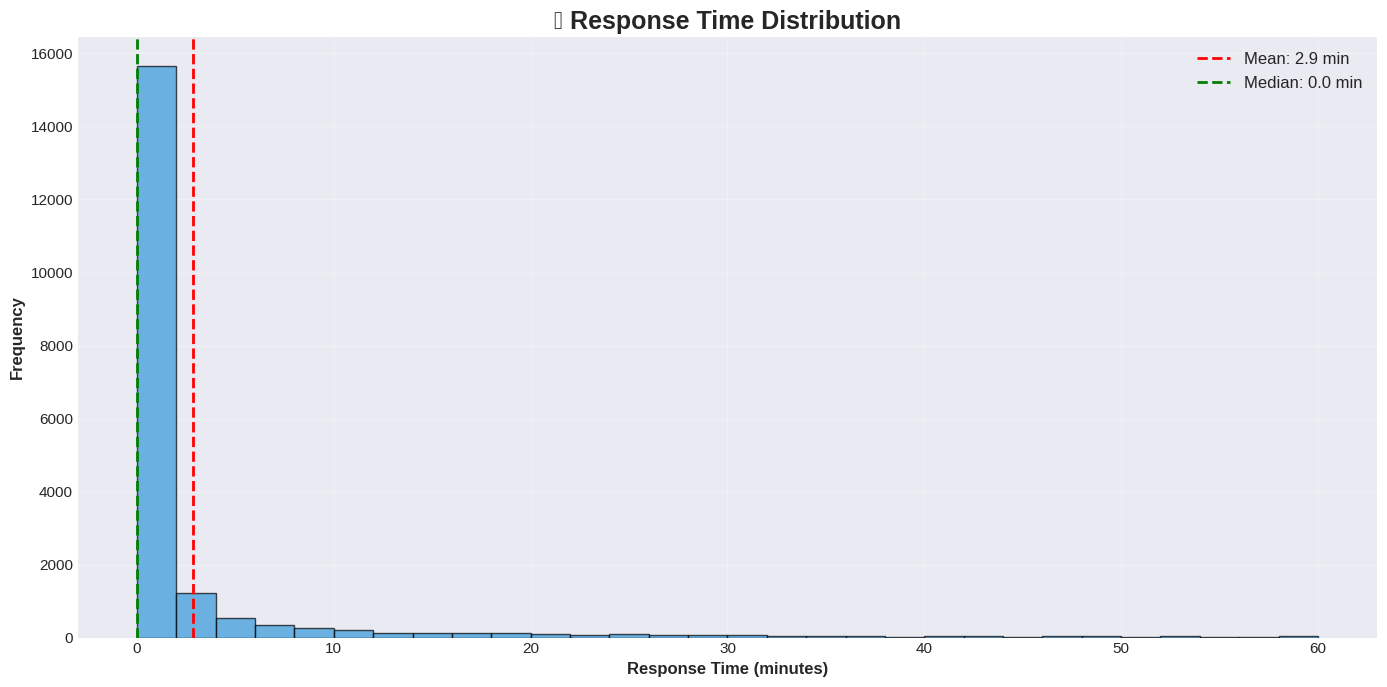

In [19]:
# Calculate time differences between messages
df_sorted = df.sort_values('datetime').copy()
df_sorted['time_diff'] = df_sorted['datetime'].diff()
df_sorted['time_diff_minutes'] = df_sorted['time_diff'].dt.total_seconds() / 60

# Filter reasonable response times (< 60 minutes)
response_times = df_sorted[df_sorted['time_diff_minutes'] <= 60]['time_diff_minutes']

print(" RESPONSE TIME ANALYSIS")
print("="*60)
print(f"Average Response Time: {response_times.mean():.2f} minutes")
print(f"Median Response Time: {response_times.median():.2f} minutes")
print(f"Fastest Response: {response_times.min():.2f} minutes")

# By member
print("\n👥 Average Response Time by Member:")
for member in df['sender'].unique():
    member_times = df_sorted[df_sorted['sender'] == member]['time_diff_minutes']
    member_times = member_times[member_times <= 60]
    if len(member_times) > 0:
        print(f"  {member:15s}: {member_times.mean():.2f} minutes")

# Visualize
fig = plt.figure(figsize=(14, 7))
plt.hist(response_times, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
plt.axvline(response_times.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {response_times.mean():.1f} min')
plt.axvline(response_times.median(), color='green', linestyle='--', linewidth=2,
           label=f'Median: {response_times.median():.1f} min')
plt.title('⚡ Response Time Distribution', fontsize=18, fontweight='bold')
plt.xlabel('Response Time (minutes)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 🌍 Step 18: Language Detection (English vs Roman Urdu)

🌍 LANGUAGE DISTRIBUTION
English: 16,979 messages (81.2%)
Urdu/Roman Urdu: 3,920 messages (18.8%)

👥 Language Preference by Member:

  Ibrahim:
    English: 83.3%
    Urdu/Roman Urdu: 16.7%

  Ahmad:
    English: 77.6%
    Urdu/Roman Urdu: 22.4%

  Bilal:
    English: 73.7%
    Urdu/Roman Urdu: 26.3%

  Asim:
    English: 80.9%
    Urdu/Roman Urdu: 19.1%

  Jawad:
    English: 79.2%
    Urdu/Roman Urdu: 20.8%

  Tayyab:
    English: 86.4%
    Urdu/Roman Urdu: 13.6%

  Hassan:
    English: 80.4%
    Urdu/Roman Urdu: 19.6%


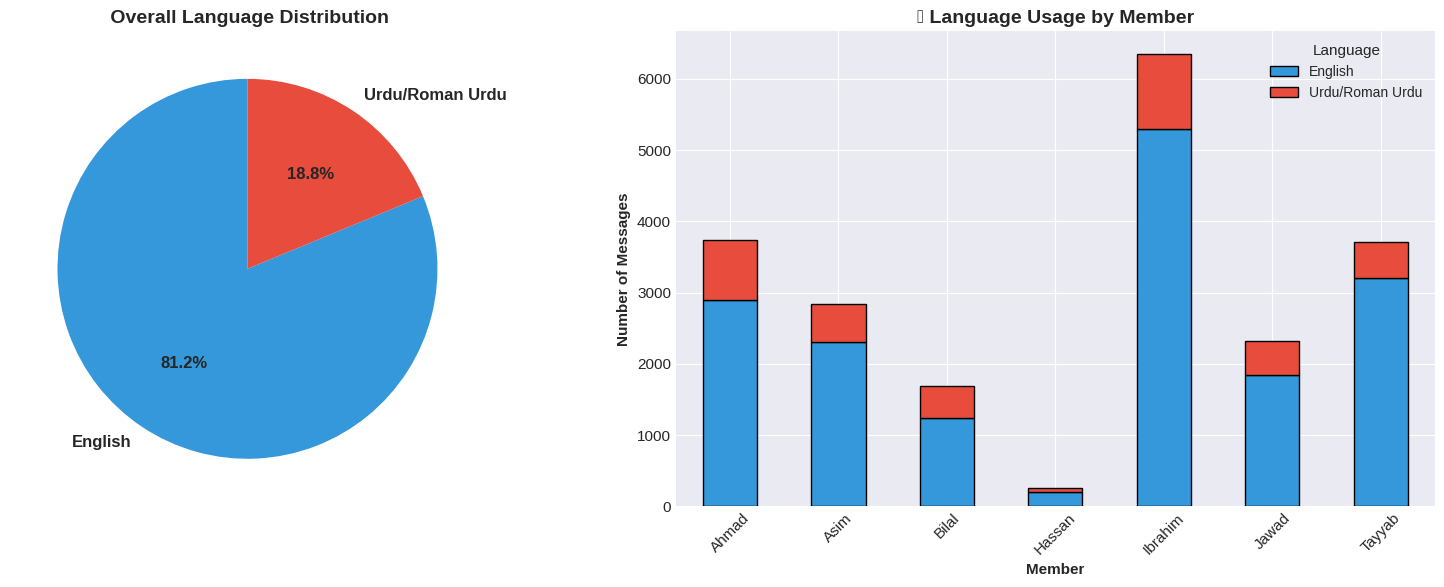

In [20]:
# Simple language detection based on common Urdu/Roman Urdu words
urdu_patterns = ['hai', 'ka', 'ki', 'ko', 'se', 'mein', 'ho', 'tha', 'thi', 
                'kar', 'kya', 'kyu', 'nahi', 'haan', 'bhai', 'yar', 'bhi', 'nhi']

def detect_language(text):
    text_lower = str(text).lower()
    urdu_count = sum(1 for pattern in urdu_patterns if pattern in text_lower)
    return 'Urdu/Roman Urdu' if urdu_count >= 2 else 'English'

df['language'] = df['message'].apply(detect_language)

# Overall distribution
lang_dist = df['language'].value_counts()
print("🌍 LANGUAGE DISTRIBUTION")
print("="*60)
for lang, count in lang_dist.items():
    percentage = (count / len(df)) * 100
    print(f"{lang}: {count:,} messages ({percentage:.1f}%)")

# By member
print("\n👥 Language Preference by Member:")
for member in df['sender'].unique():
    member_df = df[df['sender'] == member]
    lang_pref = member_df['language'].value_counts()
    print(f"\n  {member}:")
    for lang, count in lang_pref.items():
        percentage = (count / len(member_df)) * 100
        print(f"    {lang}: {percentage:.1f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
axes[0].pie(lang_dist.values, labels=lang_dist.index, autopct='%1.1f%%',
           startangle=90, colors=['#3498db', '#e74c3c'],
           textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title(' Overall Language Distribution', fontsize=14, fontweight='bold')

# Stacked bar by member
lang_by_member = df.groupby(['sender', 'language']).size().unstack(fill_value=0)
lang_by_member.plot(kind='bar', stacked=True, ax=axes[1], 
                   color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_title('👥 Language Usage by Member', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Member', fontweight='bold')
axes[1].set_ylabel('Number of Messages', fontweight='bold')
axes[1].legend(title='Language', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 📊 Step 19: Summary Statistics Table

In [21]:
# Create summary table by member
summary = df.groupby('sender').agg({
    'message': 'count',
    'message_length': 'mean',
    'word_count': 'mean',
    'is_media': 'sum',
    'has_link': 'sum',
    'has_emoji': 'sum'
}).round(2)

summary.columns = ['Total Messages', 'Avg Length', 'Avg Words', 'Media', 'Links', 'Emojis']
summary = summary.sort_values('Total Messages', ascending=False)

print("📊 MEMBER STATISTICS SUMMARY")
print("="*100)
print(summary.to_string())
print("="*100)

# Export to CSV
summary.to_csv('member_summary.csv')
print("\n✅ Summary exported to 'member_summary.csv'")

📊 MEMBER STATISTICS SUMMARY
         Total Messages  Avg Length  Avg Words  Media  Links  Emojis
sender                                                              
Ibrahim            6351       49.46       6.34   1050    404     283
Ahmad              3734       48.63       7.62    961    247      56
Tayyab             3715       56.85       8.06    730    193     104
Asim               2844       28.47       4.75    274     77     424
Jawad              2322       34.18       5.56    536     42     161
Bilal              1683      144.14      19.39    232     96      33
Hassan              250       44.47       5.17     37     30      13

✅ Summary exported to 'member_summary.csv'


## 🦉 Night Owl Analysis - Who Messages After Midnight?

**Find out who's the champion of late-night conversations!**

This analysis reveals which members are most active between 12 AM - 6 AM. Perfect for finding your group's night owls! 🌙

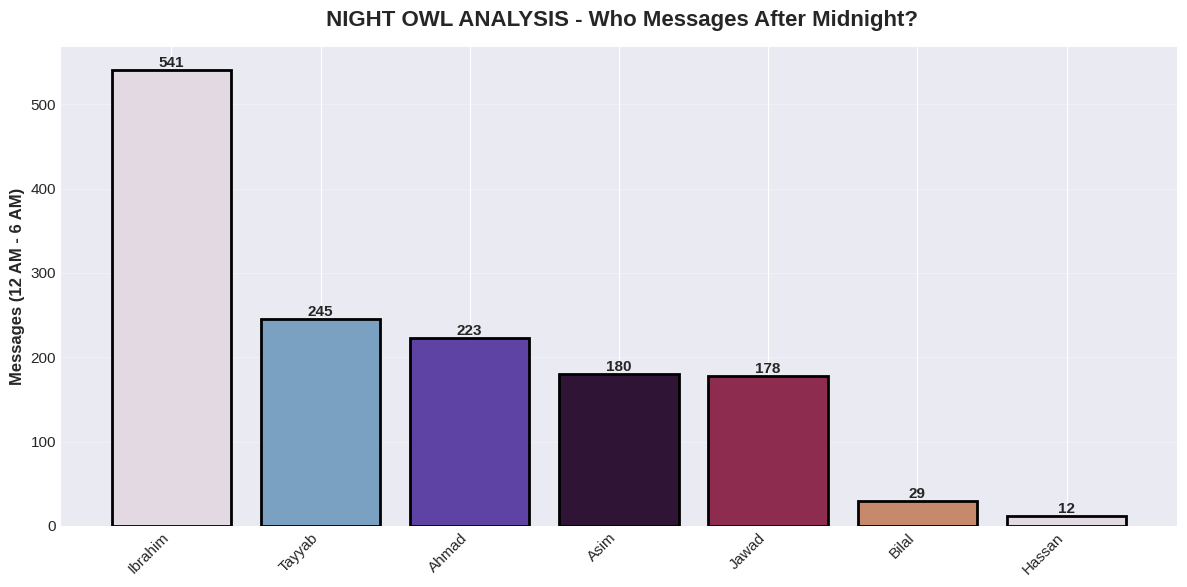

👑 Night Owl Champion: Ibrahim with 541 late-night messages!


In [22]:
# 🦉 WHO IS THE NIGHT OWL? (Late Night Activity 12 AM - 6 AM)
night_messages = df[df['is_night'] == 1].groupby('sender').size().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.twilight(np.linspace(0, 1, len(night_messages)))
bars = ax.bar(night_messages.index, night_messages.values, color=colors, edgecolor='black', linewidth=2)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title(' NIGHT OWL ANALYSIS - Who Messages After Midnight?', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Messages (12 AM - 6 AM)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print(f"👑 Night Owl Champion: {night_messages.idxmax()} with {night_messages.max()} late-night messages!")

## 💬 Conversation Starter vs Replier Analysis

**Who starts conversations vs who just replies?**

This compares how often each member initiates new conversations (after 30+ min silence) vs simply continuing existing ones. Discover your group's leaders and followers!

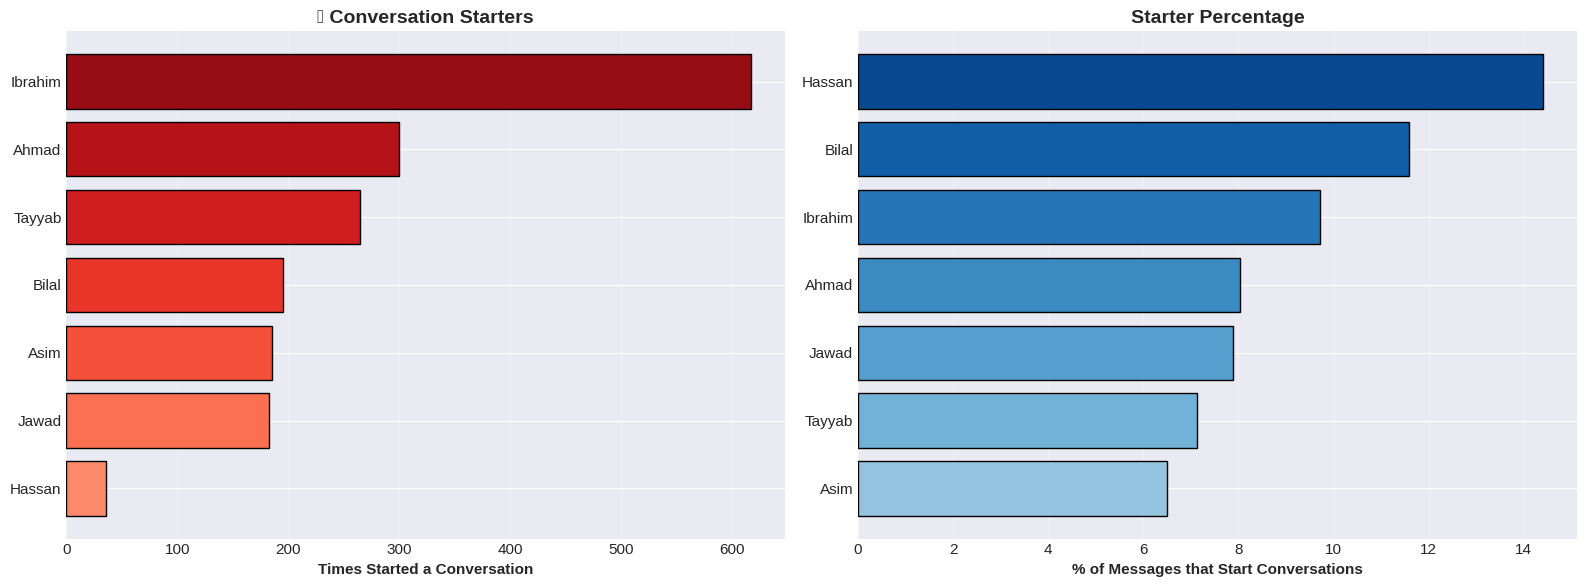


🏆 Most Likely to Start: Hassan (14.4%)
🤝 Most Likely to Reply: Asim (6.5%)


In [23]:
# 💬 CONVERSATION STARTER vs REPLIER ANALYSIS
df_sorted = df.sort_values('datetime')
df_sorted['time_gap'] = df_sorted['datetime'].diff().dt.total_seconds() / 60
df_sorted['is_starter'] = df_sorted['time_gap'] > 30  # New conversation if gap > 30 min

starters = df_sorted[df_sorted['is_starter']].groupby('sender').size()
total_msgs = df.groupby('sender').size()
starter_pct = (starters / total_msgs * 100).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors1 = plt.cm.Reds(np.linspace(0.4, 0.9, len(starters)))
colors2 = plt.cm.Blues(np.linspace(0.4, 0.9, len(starter_pct)))

ax1.barh(starters.sort_values().index, starters.sort_values().values, color=colors1, edgecolor='black')
ax1.set_title('🚀 Conversation Starters', fontsize=14, fontweight='bold')
ax1.set_xlabel('Times Started a Conversation', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

ax2.barh(starter_pct.sort_values().index, starter_pct.sort_values().values, color=colors2, edgecolor='black')
ax2.set_title('Starter Percentage', fontsize=14, fontweight='bold')
ax2.set_xlabel('% of Messages that Start Conversations', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print(f"\n🏆 Most Likely to Start: {starter_pct.idxmax()} ({starter_pct.max():.1f}%)")
print(f"🤝 Most Likely to Reply: {starter_pct.idxmin()} ({starter_pct.min():.1f}%)")

## 👻 Ghosting Analysis - When Did the Group Almost Die?

**The longest silences in your group's history!**

Find out the biggest gaps between messages and who broke the ice. This shows when your group went completely silent and who saved it! 😱

👻 TOP 10 LONGEST SILENCES (Group Almost Died):

74.5 hours - Then Ibrahim broke the silence!
   Said: Anything you wanna add or anything you wanted to remove or any other pov let me ...

72.4 hours - Then Asim broke the silence!
   Said: https://docs.google.com/document/d/14aSeMirO48dQ2Wzc1ZO5B5_1QhaTz2NTfqgm8VuPuZM/...

66.8 hours - Then Ibrahim broke the silence!
   Said: Find my name 🫣...

64.7 hours - Then Ibrahim broke the silence!
   Said: ...

56.5 hours - Then Hassan broke the silence!
   Said: <Media omitted>...

50.8 hours - Then Jawad broke the silence!
   Said: I see the whole site... Amazing as always but need some changes like:
- Navbar h...

47.9 hours - Then Ahmad broke the silence!
   Said: <Media omitted>...

47.4 hours - Then Jawad broke the silence!
   Said: aj apna last Codeinplace ka session dyny kay bad...agy kia 🫠🫠🫠🫠🫠🫠 <This message ...

46.6 hours - Then Asim broke the silence!
   Said: I’ll do it as well...

46.3 hours - Then Ibrahim broke the silence!
   Said

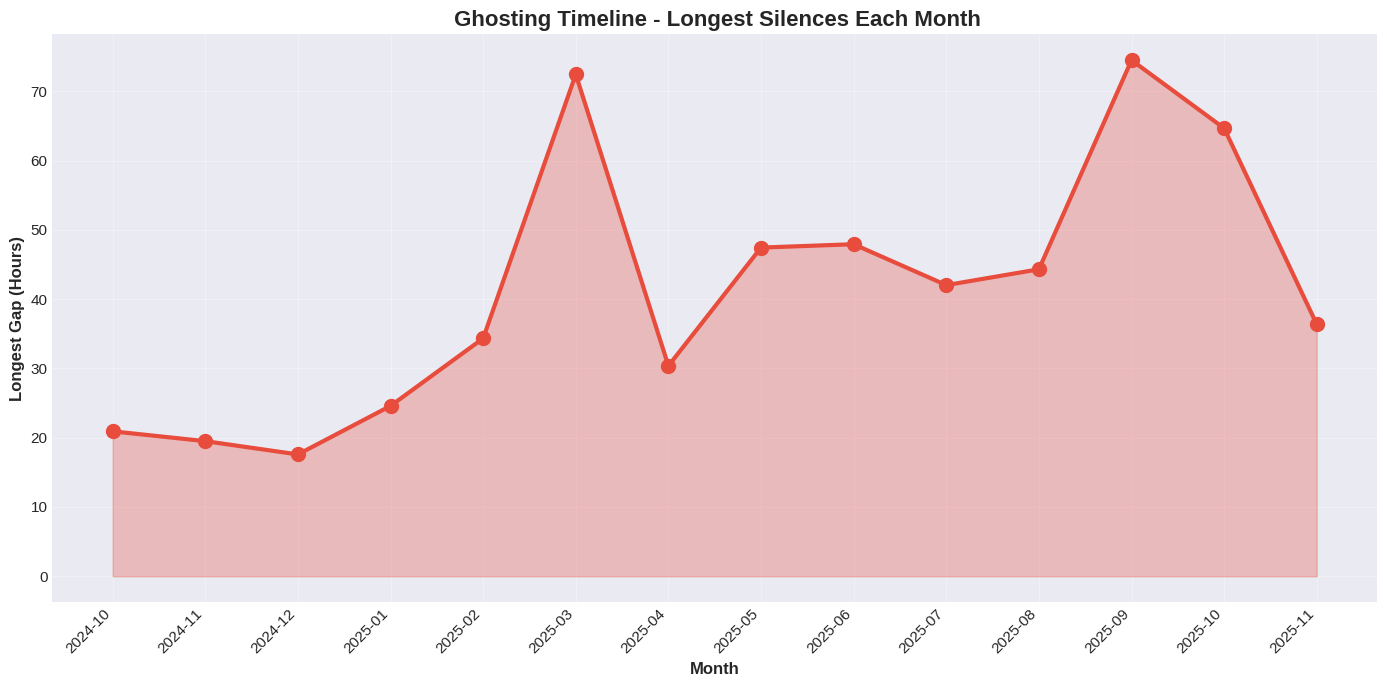

In [24]:
# 👻 GHOSTING ANALYSIS - Longest Silence Periods
df_sorted = df.sort_values('datetime')
df_sorted['gap_hours'] = df_sorted['datetime'].diff().dt.total_seconds() / 3600
top_gaps = df_sorted.nlargest(10, 'gap_hours')[['datetime', 'sender', 'gap_hours', 'message']]
print("👻 TOP 10 LONGEST SILENCES (Group Almost Died):\n")
for i, row in top_gaps.iterrows():
    print(f"{row['gap_hours']:.1f} hours - Then {row['sender']} broke the silence!")
    print(f"   Said: {row['message'][:80]}...\n")

# Visualize
fig = plt.figure(figsize=(14, 7))
gaps_by_month = df_sorted.groupby(df_sorted['datetime'].dt.to_period('M'))['gap_hours'].max()
plt.plot(gaps_by_month.index.astype(str), gaps_by_month.values, marker='o', 
         linewidth=3, markersize=10, color='#e74c3c')
plt.fill_between(range(len(gaps_by_month)), gaps_by_month.values, alpha=0.3, color='#e74c3c')
plt.title(' Ghosting Timeline - Longest Silences Each Month', fontsize=16, fontweight='bold')
plt.ylabel('Longest Gap (Hours)', fontsize=12, fontweight='bold')
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 🎭 Message Personality Test - What's Your Texting Style?

**Are you a speedster or a novelist?**

Based on average message length, this categorizes each member into personality types:
- 💨 Speedster (short messages)
- 💬 Conversationalist (balanced)
- 📝 Storyteller (detailed)
- 📚 Novelist (epic paragraphs)

🎭 MESSAGE PERSONALITY TYPES:

  Ahmad: 💬 The Conversationalist (Balanced)
  Asim: 💨 The Speedster (Quick & Brief)
  Bilal: 📚 The Novelist (Epic Messages)
  Hassan: 💬 The Conversationalist (Balanced)
  Ibrahim: 💬 The Conversationalist (Balanced)
  Jawad: 💬 The Conversationalist (Balanced)
  Tayyab: 💬 The Conversationalist (Balanced)


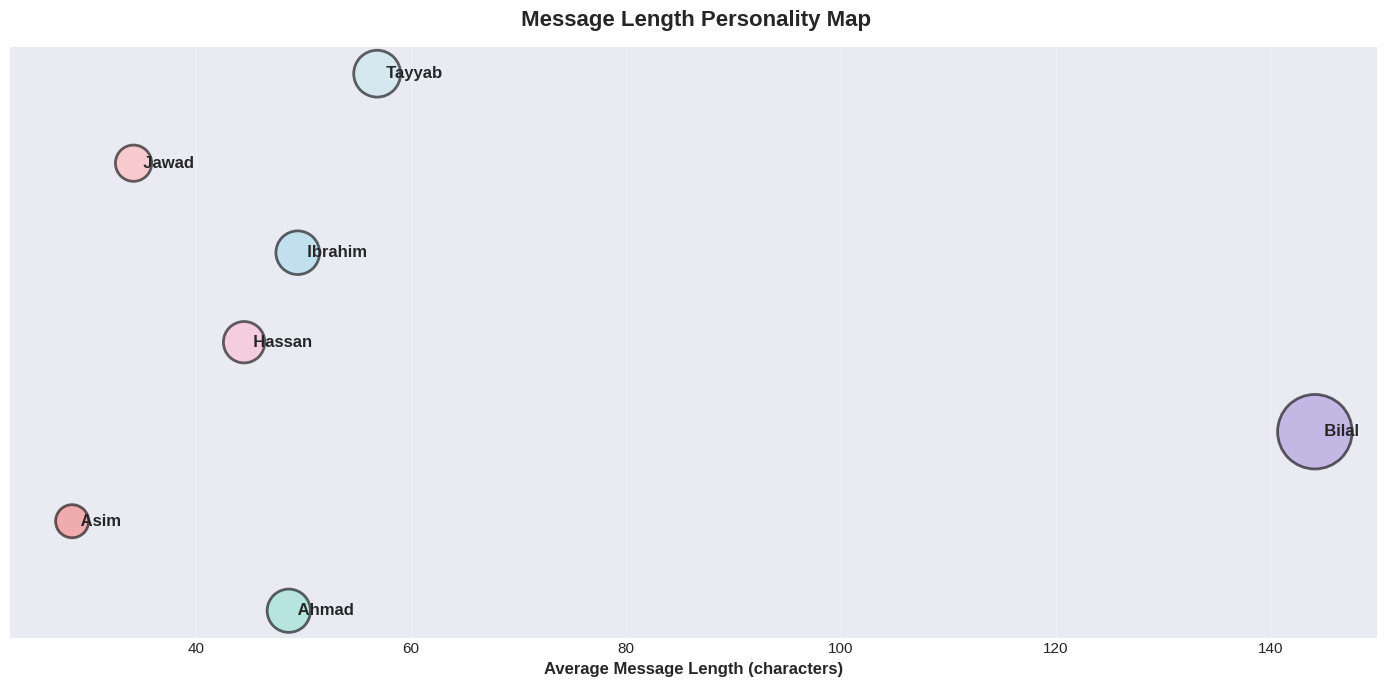

In [25]:
# 🎭 MESSAGE LENGTH PERSONALITY TEST
avg_length = df.groupby('sender')['message_length'].mean()
personalities = []
for member, length in avg_length.items():
    if length < 30:
        personalities.append(f"{member}: 💨 The Speedster (Quick & Brief)")
    elif length < 60:
        personalities.append(f"{member}: 💬 The Conversationalist (Balanced)")
    elif length < 100:
        personalities.append(f"{member}: 📝 The Storyteller (Detailed)")
    else:
        personalities.append(f"{member}: 📚 The Novelist (Epic Messages)")

print("🎭 MESSAGE PERSONALITY TYPES:\n")
for p in personalities:
    print(f"  {p}")

fig = plt.figure(figsize=(14, 7))
colors = ['#95e1d3', '#f38181', '#aa96da', '#fcbad3', '#a8d8ea', '#ffb6b9', '#c8e7ed'][:len(avg_length)]
plt.scatter(avg_length.values, range(len(avg_length)), s=avg_length.values*20, 
           c=colors, alpha=0.6, edgecolors='black', linewidth=2)
for i, (member, length) in enumerate(avg_length.items()):
    plt.text(length, i, f'  {member}', fontsize=12, fontweight='bold', va='center')
plt.title(' Message Length Personality Map', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Average Message Length (characters)', fontsize=12, fontweight='bold')
plt.yticks([])
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 🔥 Controversy Meter - When Does the Group Get LIT?

**Which hours have the most chaotic activity?**

This identifies peak chaos times by combining high message volume with high variance. These are the hours when things get WILD in your group! 💥

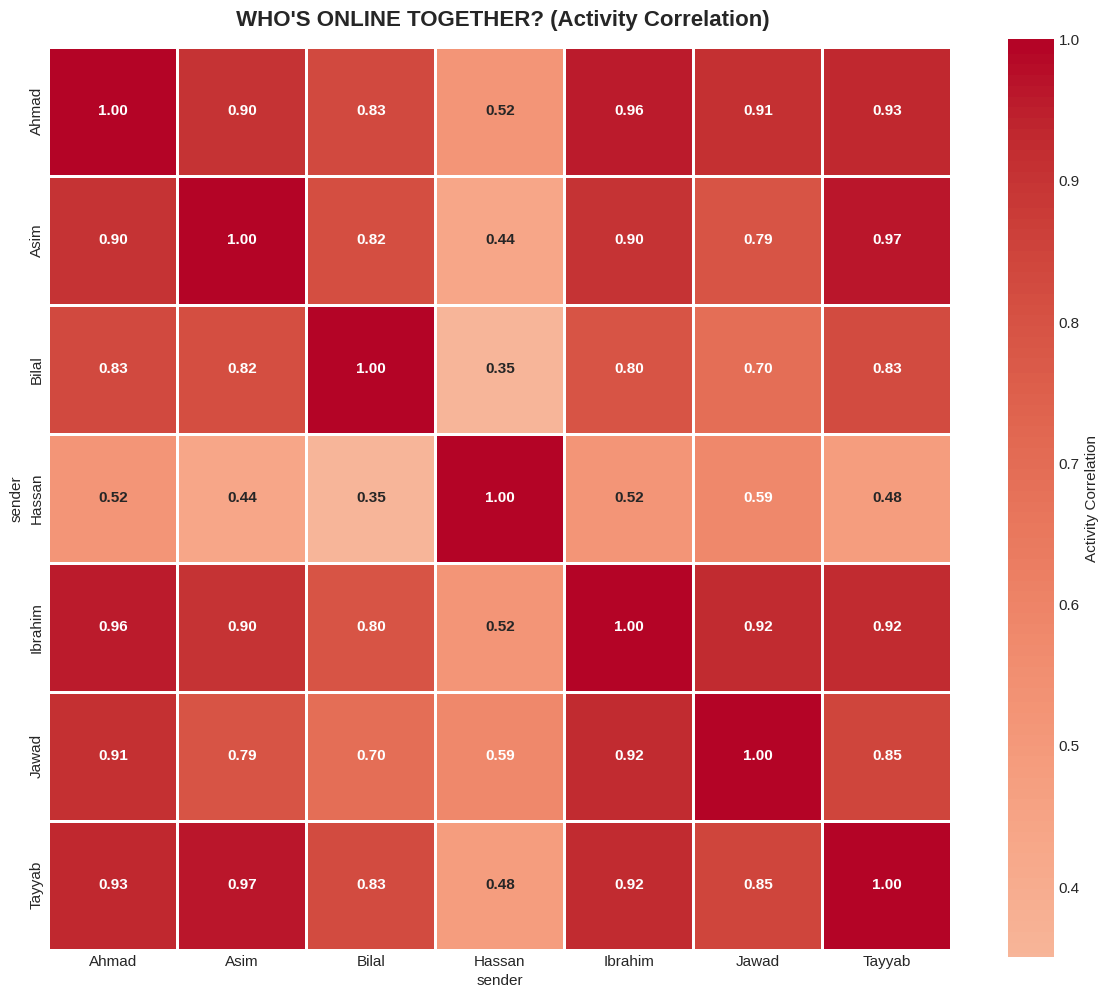


🔍 Interpretation:
  • Close to 1.0 = Often active at same times
  • Close to 0.0 = Independent schedules
  • Negative = When one is active, other is not


In [26]:
# 💥 MEMBER ACTIVITY CORRELATION HEATMAP (Who's Active Together?)
hourly_activity = df.pivot_table(index='hour', columns='sender', values='message', aggfunc='count', fill_value=0)
correlation = hourly_activity.corr()

fig = plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=2,
            cbar_kws={'label': 'Activity Correlation'},
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
plt.title(' WHO\'S ONLINE TOGETHER? (Activity Correlation)', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print("\n🔍 Interpretation:")
print("  • Close to 1.0 = Often active at same times")
print("  • Close to 0.0 = Independent schedules")
print("  • Negative = When one is active, other is not")

## 💥 Activity Correlation - Who's Online Together?

**Find out which members are active at the same times!**

This correlation heatmap shows which members have similar activity patterns. Values close to 1.0 mean they're often online together!

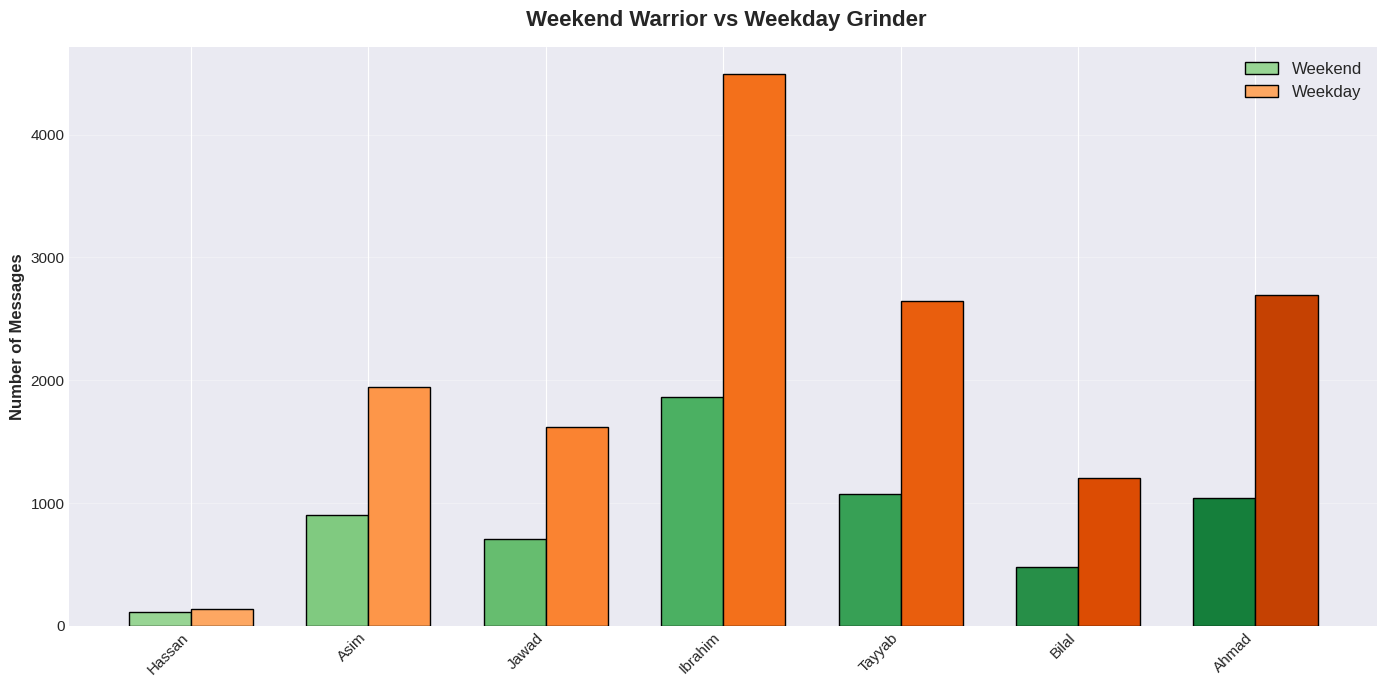


🏖️ Weekend Champion: Hassan (45.6% weekend activity)
💼 Weekday Warrior: Ahmad (72.2% weekday activity)


In [27]:
# 🎯 WEEKEND WARRIOR vs WEEKDAY GRINDER
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])
weekend_msgs = df[df['is_weekend']].groupby('sender').size()
weekday_msgs = df[~df['is_weekend']].groupby('sender').size()
weekend_ratio = (weekend_msgs / (weekend_msgs + weekday_msgs) * 100).sort_values(ascending=False)

fig = plt.figure(figsize=(14, 7))
x = np.arange(len(weekend_ratio))
width = 0.35
colors_we = plt.cm.Greens(np.linspace(0.4, 0.8, len(weekend_ratio)))
colors_wd = plt.cm.Oranges(np.linspace(0.4, 0.8, len(weekend_ratio)))

plt.bar(x - width/2, weekend_msgs.reindex(weekend_ratio.index), width, 
        label='Weekend', color=colors_we, edgecolor='black')
plt.bar(x + width/2, weekday_msgs.reindex(weekend_ratio.index), width,
        label='Weekday', color=colors_wd, edgecolor='black')

plt.title(' Weekend Warrior vs Weekday Grinder', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Number of Messages', fontsize=12, fontweight='bold')
plt.xticks(x, weekend_ratio.index, rotation=45, ha='right')
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n🏖️ Weekend Champion: {weekend_ratio.idxmax()} ({weekend_ratio.max():.1f}% weekend activity)")
print(f"💼 Weekday Warrior: {weekend_ratio.idxmin()} ({100-weekend_ratio.min():.1f}% weekday activity)")

## 🎪 Emoji Royalty - Who's the Emoji King/Queen?

**Which member uses the most emojis?**

Find out who loves emojis and who keeps it plain! This shows the percentage of messages containing emojis for each member. 👑😊

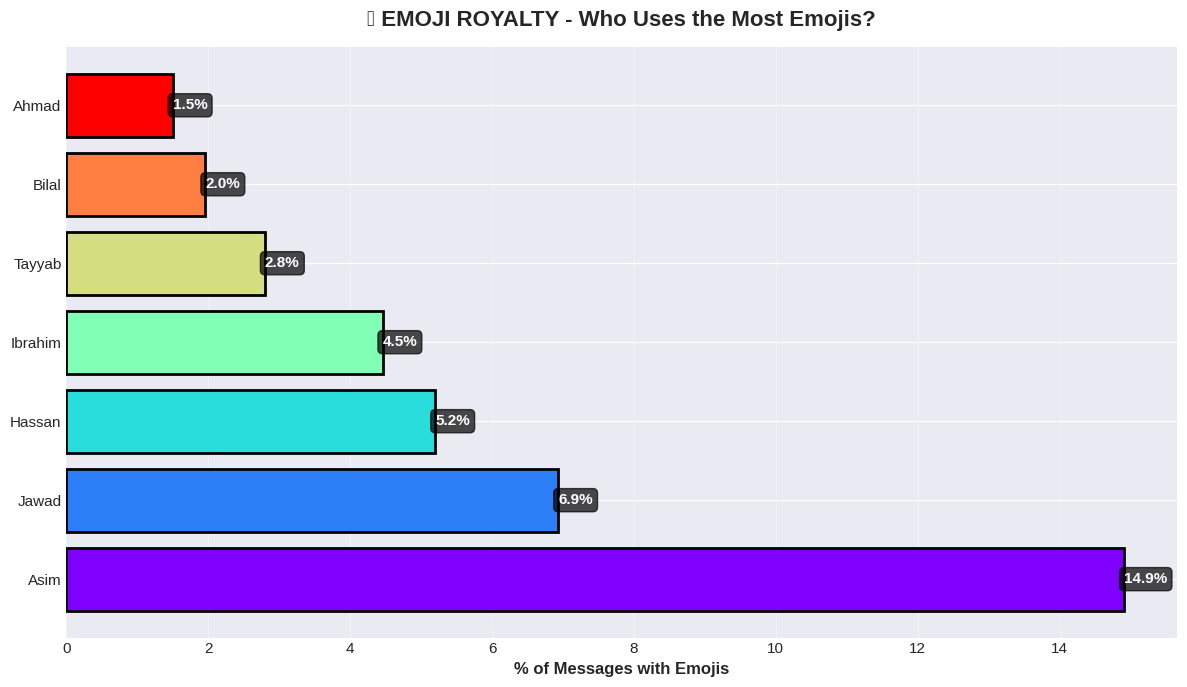


👑 Emoji King/Queen: Asim (14.9% of messages have emojis)
😐 Emoji Minimalist: Ahmad (1.5% of messages have emojis)


In [28]:
# 🎪 EMOJI KING/QUEEN ANALYSIS (If has_emoji column exists)
if df['has_emoji'].any():
    emoji_lovers = df[df['has_emoji']].groupby('sender').size()
    emoji_rate = (emoji_lovers / df.groupby('sender').size() * 100).sort_values(ascending=False)
    
    fig = plt.figure(figsize=(12, 7))
    colors = plt.cm.rainbow(np.linspace(0, 1, len(emoji_rate)))
    bars = plt.barh(emoji_rate.index, emoji_rate.values, color=colors, edgecolor='black', linewidth=2)
    
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2., f'{width:.1f}%',
                ha='left', va='center', fontsize=11, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    plt.title('🎪 EMOJI ROYALTY - Who Uses the Most Emojis?', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('% of Messages with Emojis', fontsize=12, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"\n👑 Emoji King/Queen: {emoji_rate.idxmax()} ({emoji_rate.max():.1f}% of messages have emojis)")
    print(f"😐 Emoji Minimalist: {emoji_rate.idxmin()} ({emoji_rate.min():.1f}% of messages have emojis)")

## 🌟 Group Evolution - The Complete Journey

**How has your group changed over time?**

This deep analysis shows 3 trends over months:
1. **Message Volume** - How active the group has been
2. **Active Members** - How many people participated
3. **Message Depth** - How detailed conversations were

Perfect for understanding your group's story! 📖

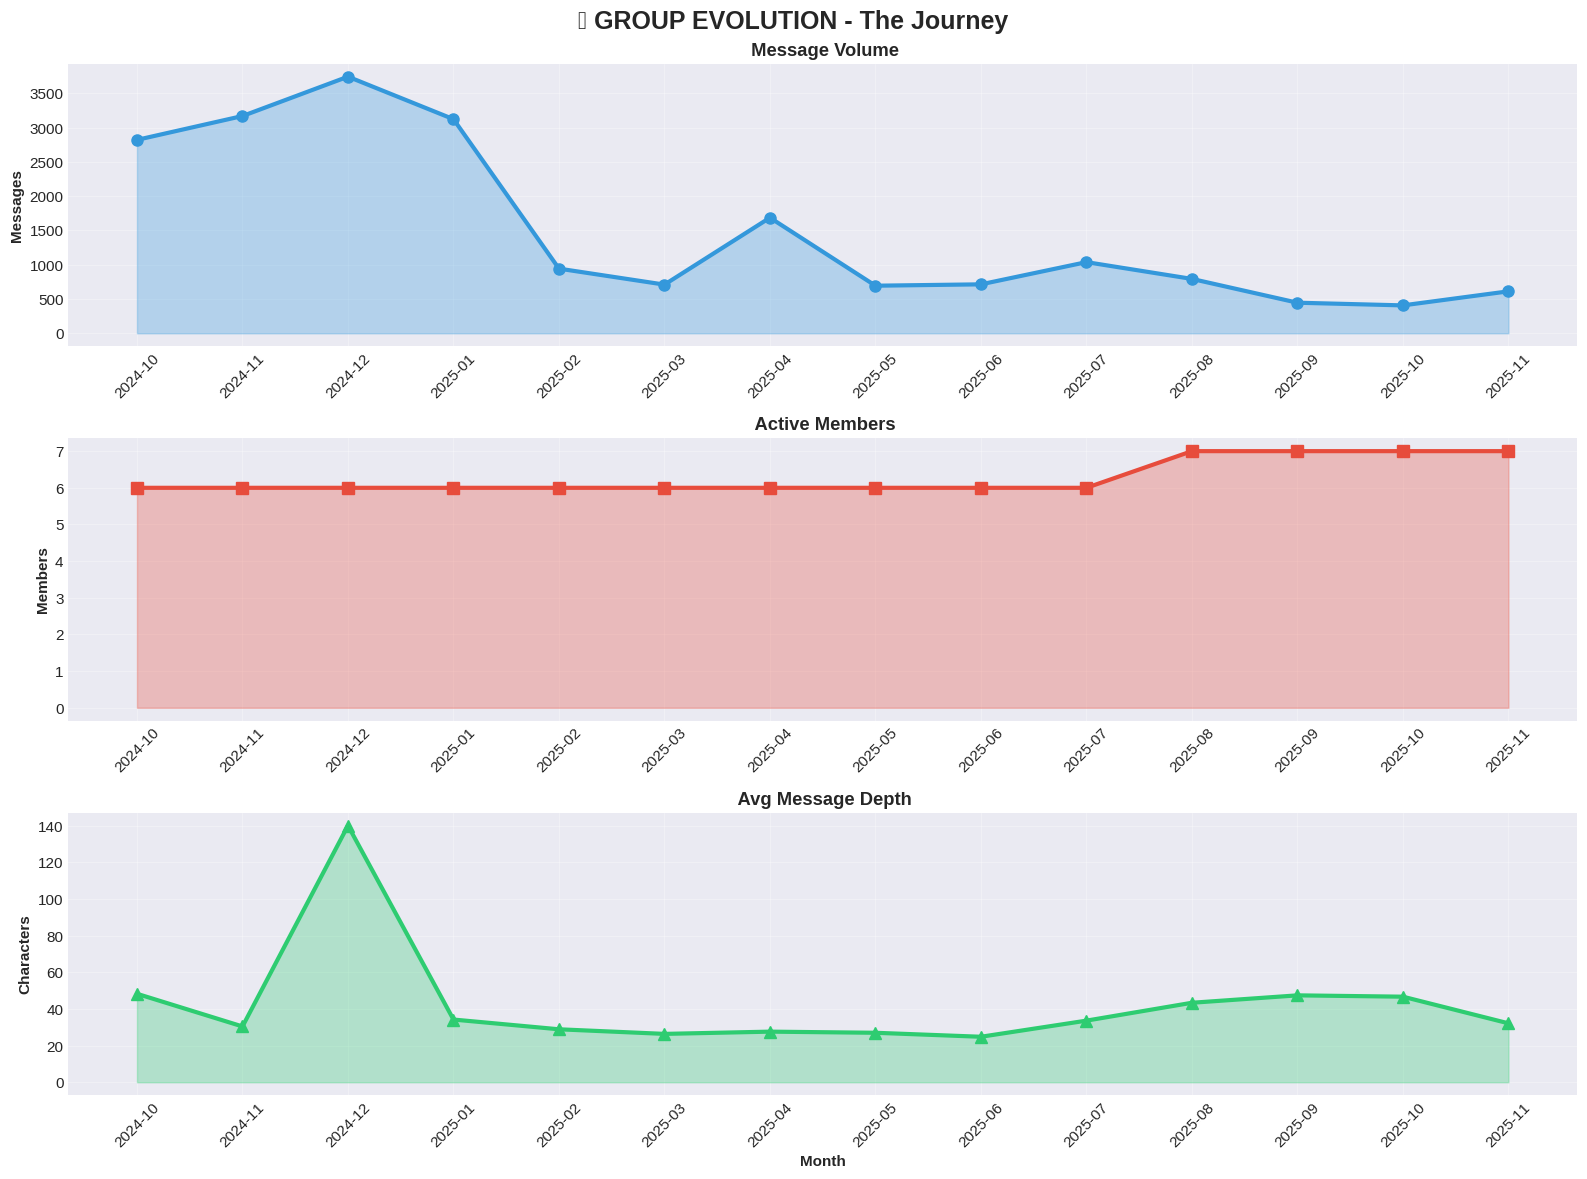


🌟 DEEP INSIGHT:
  Peak Activity: 2024-12 (3743 messages)
  Most Engaged: 2025-08 (7 active members)
  Deepest Convos: 2024-12 (avg 140 chars)


In [29]:
# 🌟 FINAL DEEP INSIGHT - Group Evolution Over Time
monthly_stats = df.groupby(df['datetime'].dt.to_period('M')).agg({
    'message': 'count',
    'sender': 'nunique',
    'message_length': 'mean'
})

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('🌟 GROUP EVOLUTION - The Journey', fontsize=18, fontweight='bold')

axes[0].plot(monthly_stats.index.astype(str), monthly_stats['message'], 
            marker='o', linewidth=3, markersize=8, color='#3498db')
axes[0].fill_between(range(len(monthly_stats)), monthly_stats['message'], alpha=0.3, color='#3498db')
axes[0].set_title(' Message Volume', fontweight='bold')
axes[0].set_ylabel('Messages', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(monthly_stats.index.astype(str), monthly_stats['sender'],
            marker='s', linewidth=3, markersize=8, color='#e74c3c')
axes[1].fill_between(range(len(monthly_stats)), monthly_stats['sender'], alpha=0.3, color='#e74c3c')
axes[1].set_title(' Active Members', fontweight='bold')
axes[1].set_ylabel('Members', fontweight='bold')
axes[1].grid(alpha=0.3)

axes[2].plot(monthly_stats.index.astype(str), monthly_stats['message_length'],
            marker='^', linewidth=3, markersize=8, color='#2ecc71')
axes[2].fill_between(range(len(monthly_stats)), monthly_stats['message_length'], alpha=0.3, color='#2ecc71')
axes[2].set_title(' Avg Message Depth', fontweight='bold')
axes[2].set_ylabel('Characters', fontweight='bold')
axes[2].set_xlabel('Month', fontweight='bold')
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("\n🌟 DEEP INSIGHT:")
print(f"  Peak Activity: {monthly_stats['message'].idxmax()} ({monthly_stats['message'].max()} messages)")
print(f"  Most Engaged: {monthly_stats['sender'].idxmax()} ({monthly_stats['sender'].max()} active members)")
print(f"  Deepest Convos: {monthly_stats['message_length'].idxmax()} (avg {monthly_stats['message_length'].max():.0f} chars)")

## 💾 Step 20: Export Complete Dataset to CSV

In [30]:
# Export full dataset
output_file = 'whatsapp_chat_data_complete.csv'
df.to_csv(output_file, index=False, encoding='utf-8')

print(f"✅ Complete dataset exported to: {output_file}")
print(f"\n📊 Dataset Info:")
print(f"  - Rows: {len(df):,}")
print(f"  - Columns: {len(df.columns)}")
print(f"  - Size: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")
print(f"\nColumns: {list(df.columns)}")

✅ Complete dataset exported to: whatsapp_chat_data_complete.csv

📊 Dataset Info:
  - Rows: 20,899
  - Columns: 20
  - Size: 11.21 MB

Columns: ['date', 'time', 'datetime', 'sender', 'message', 'day_of_week', 'hour', 'month', 'year', 'message_length', 'word_count', 'is_media', 'has_link', 'has_emoji', 'is_night', 'is_morning', 'is_afternoon', 'is_evening', 'language', 'is_weekend']


## 🎉 ANALYSIS COMPLETED 
# its for my btaji Crew :)
FOLLOW ME FOR MORE =)

